In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore, kruskal # kruskal might be useful later, zscore for this task
# For Windrose (if not installed: pip install windrose)
from windrose import WindroseAxes

# Configure plot styles for better visualization
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6) # Default figure size
plt.rcParams['figure.dpi'] = 100 # High resolution for plots

In [2]:
# Path to the raw data file (assuming notebook is in 'notebooks' and data is in 'data')
file_path = '../data/' + 'togo-dapaong_qc.csv' # temporarily breaking it up
df_benin = pd.read_csv(file_path)

print("Original DataFrame Info:")
df_benin.info()
print("\nFirst 5 rows of the dataset:")
print(df_benin.head())

Original DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Timestamp      525600 non-null  object 
 1   GHI            525600 non-null  float64
 2   DNI            525600 non-null  float64
 3   DHI            525600 non-null  float64
 4   ModA           525600 non-null  float64
 5   ModB           525600 non-null  float64
 6   Tamb           525600 non-null  float64
 7   RH             525600 non-null  float64
 8   WS             525600 non-null  float64
 9   WSgust         525600 non-null  float64
 10  WSstdev        525600 non-null  float64
 11  WD             525600 non-null  float64
 12  WDstdev        525600 non-null  float64
 13  BP             525600 non-null  int64  
 14  Cleaning       525600 non-null  int64  
 15  Precipitation  525600 non-null  float64
 16  TModA          525600 non-null  float64
 17  TMod

In [3]:
print("\nDescriptive Statistics for Numeric Columns:")
print(df_benin.describe())


Descriptive Statistics for Numeric Columns:
                 GHI            DNI            DHI           ModA  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      230.555040     151.258469     116.444352     226.144375   
std       322.532347     250.956962     156.520714     317.346938   
min       -12.700000       0.000000       0.000000       0.000000   
25%        -2.200000       0.000000       0.000000       0.000000   
50%         2.100000       0.000000       2.500000       4.400000   
75%       442.400000     246.400000     215.700000     422.525000   
max      1424.000000    1004.500000     805.700000    1380.000000   

                ModB           Tamb             RH             WS  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      219.568588      27.751788      55.013160       2.368093   
std       307.932510       4.758023      28.778732       1.462668   
min         0.000000      14.900000       3.300000       

In [4]:
print("\nMissing Values Report:")
missing_values = df_benin.isnull().sum()
missing_percentage = (missing_values / len(df_benin)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

# Sort by percentage descending
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print(missing_df)

# List columns with >5% nulls
high_null_cols = missing_df[missing_df['Missing Percentage'] > 5].index.tolist()
if high_null_cols:
    print(f"\nColumns with more than 5% missing values: {high_null_cols}")
else:
    print("\nNo columns with more than 5% missing values.")


Missing Values Report:
          Missing Count  Missing Percentage
Comments         525600               100.0

Columns with more than 5% missing values: ['Comments']



Checking for non-physical values (e.g., negative GHI, DNI, DHI):
Column 'GHI' has 257385 negative values. These should be addressed.


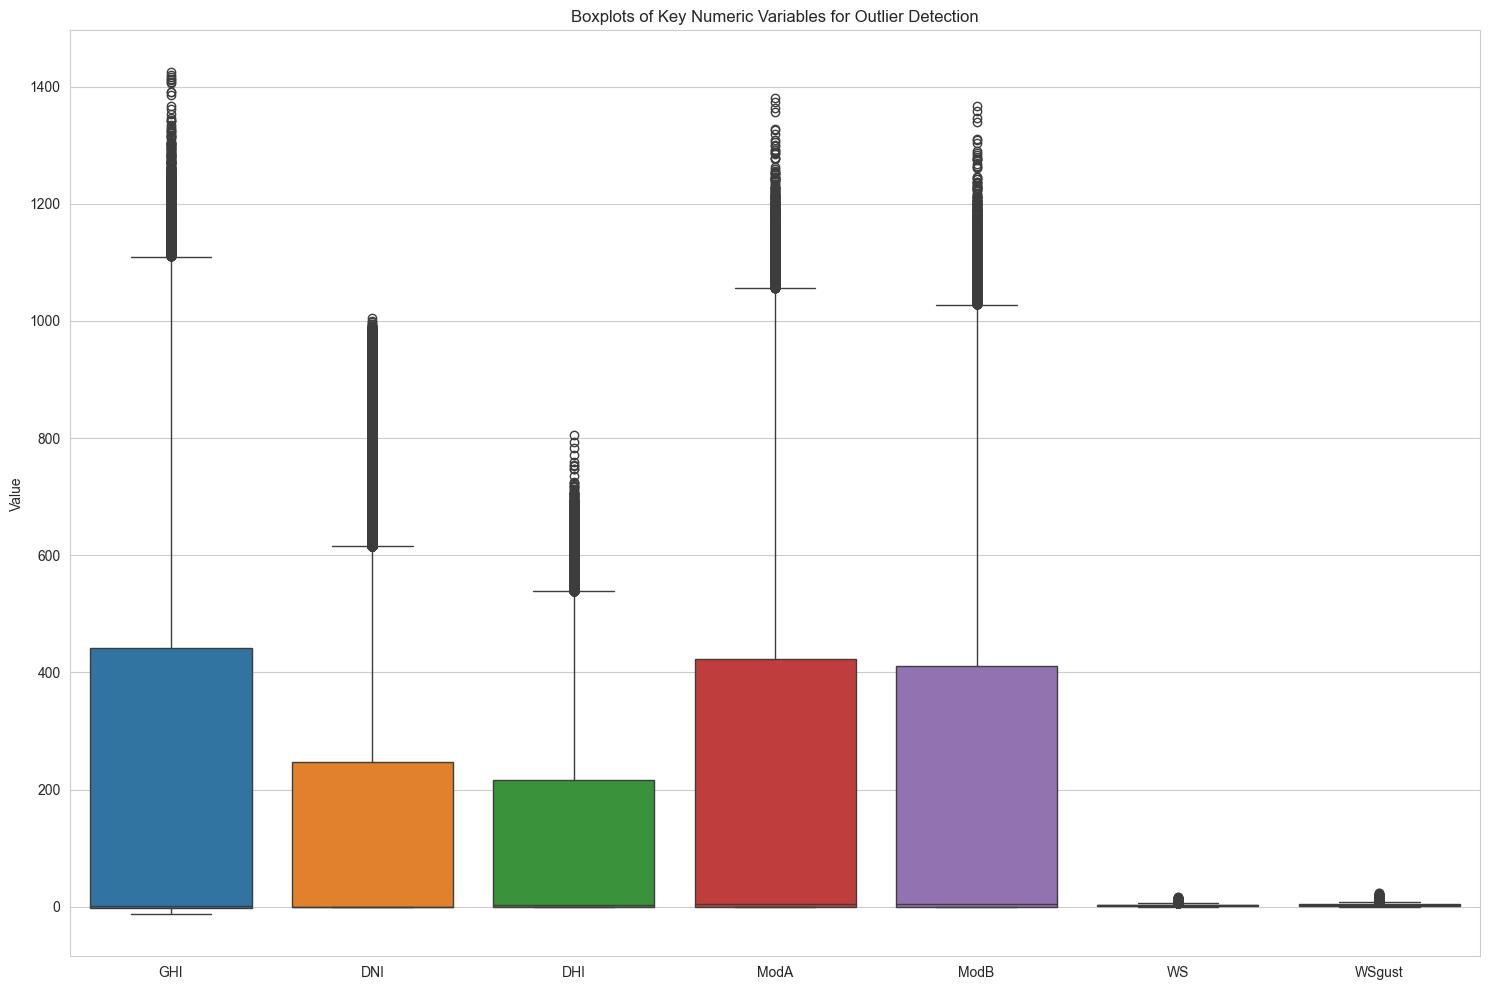

In [5]:
# Convert 'Timestamp' to datetime objects and set as index
df_benin['Timestamp'] = pd.to_datetime(df_benin['Timestamp'])
df_benin = df_benin.set_index('Timestamp')

# Quick check for non-physical values (e.g., negative solar irradiance)
print("\nChecking for non-physical values (e.g., negative GHI, DNI, DHI):")
for col in ['GHI', 'DNI', 'DHI']:
    negative_values = df_benin[df_benin[col] < 0][col].count()
    if negative_values > 0:
        print(f"Column '{col}' has {negative_values} negative values. These should be addressed.")

# Visualize distributions with boxplots for outlier detection
plt.figure(figsize=(15, 10))
sns.boxplot(data=df_benin[['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']])
plt.title('Boxplots of Key Numeric Variables for Outlier Detection')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

In [6]:
outlier_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
df_benin_clean = df_benin.copy() # Work on a copy for cleaning

# Initialize an 'outlier_flag' column to False
df_benin_clean['outlier_flag'] = False

for col in outlier_cols:
    # Calculate Z-scores, handling NaNs
    # Store original values before potential imputation/dropping for cleaning impact analysis
    df_benin_clean[f'{col}_original'] = df_benin_clean[col]
    
    # Only calculate z-score for non-null values
    valid_data = df_benin_clean[col].dropna()
    if not valid_data.empty:
        z_scores = np.abs(zscore(valid_data))
        # Get the indices of outliers in the valid_data series
        outlier_indices = valid_data[z_scores > 3].index
        # Flag these rows in the main DataFrame
        df_benin_clean.loc[outlier_indices, 'outlier_flag'] = True
        print(f"Found {len(outlier_indices)} outliers in '{col}' (Z-score > 3).")
    else:
        print(f"Column '{col}' is entirely NaN, skipping Z-score calculation.")

total_flagged_outliers = df_benin_clean['outlier_flag'].sum()
print(f"\nTotal rows flagged as outliers across specified columns: {total_flagged_outliers}")

Found 305 outliers in 'GHI' (Z-score > 3).
Found 1062 outliers in 'DNI' (Z-score > 3).
Found 3415 outliers in 'DHI' (Z-score > 3).
Found 137 outliers in 'ModA' (Z-score > 3).
Found 206 outliers in 'ModB' (Z-score > 3).
Found 3510 outliers in 'WS' (Z-score > 3).
Found 3915 outliers in 'WSgust' (Z-score > 3).

Total rows flagged as outliers across specified columns: 9251


In [7]:
# Handle negative solar irradiance values: set to 0 or NaN, then impute
for col in ['GHI', 'DNI', 'DHI']:
    df_benin_clean.loc[df_benin_clean[col] < 0, col] = np.nan # Convert negatives to NaN

# Impute missing values for key continuous variables with their median
impute_cols = ['GHI', 'DNI', 'DHI', 'Tamb', 'RH', 'BP', 'WS', 'WSgust', 'WD', 'ModA', 'ModB']
for col in impute_cols:
    if df_benin_clean[col].isnull().any():
        median_val = df_benin_clean[col].median()
        df_benin_clean[col].fillna(median_val, inplace=True)
        print(f"Imputed missing values in '{col}' with median: {median_val}")

# Drop rows flagged as outliers
initial_rows = len(df_benin_clean)
df_benin_clean = df_benin_clean[~df_benin_clean['outlier_flag']].copy() # Keep only non-outlier rows
rows_after_outlier_drop = len(df_benin_clean)
print(f"\nDropped {initial_rows - rows_after_outlier_drop} rows flagged as outliers.")

# Drop the temporary '_original' and 'outlier_flag' columns if no longer needed
df_benin_clean.drop(columns=[col for col in df_benin_clean.columns if '_original' in col or 'outlier_flag' in col], inplace=True, errors='ignore')

print("\nDataFrame after cleaning:")
df_benin_clean.info()

Imputed missing values in 'GHI' with median: 430.3

Dropped 9251 rows flagged as outliers.

DataFrame after cleaning:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 516349 entries, 2021-10-25 00:01:00 to 2022-10-25 00:00:00
Data columns (total 18 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   GHI            516349 non-null  float64
 1   DNI            516349 non-null  float64
 2   DHI            516349 non-null  float64
 3   ModA           516349 non-null  float64
 4   ModB           516349 non-null  float64
 5   Tamb           516349 non-null  float64
 6   RH             516349 non-null  float64
 7   WS             516349 non-null  float64
 8   WSgust         516349 non-null  float64
 9   WSstdev        516349 non-null  float64
 10  WD             516349 non-null  float64
 11  WDstdev        516349 non-null  float64
 12  BP             516349 non-null  int64  
 13  Cleaning       516349 non-null  int64  
 14  Precipitatio

C:\Users\DELL 7020\AppData\Local\Temp\ipykernel_9024\3533472070.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_benin_clean[col].fillna(median_val, inplace=True)


In [8]:
output_path = '../data/togo_eda.csv'
df_benin_clean.to_csv(output_path, index=True) # index=True to save Timestamp as a column
print(f"\nCleaned data exported to {output_path}")


Cleaned data exported to ../data/togo_eda.csv


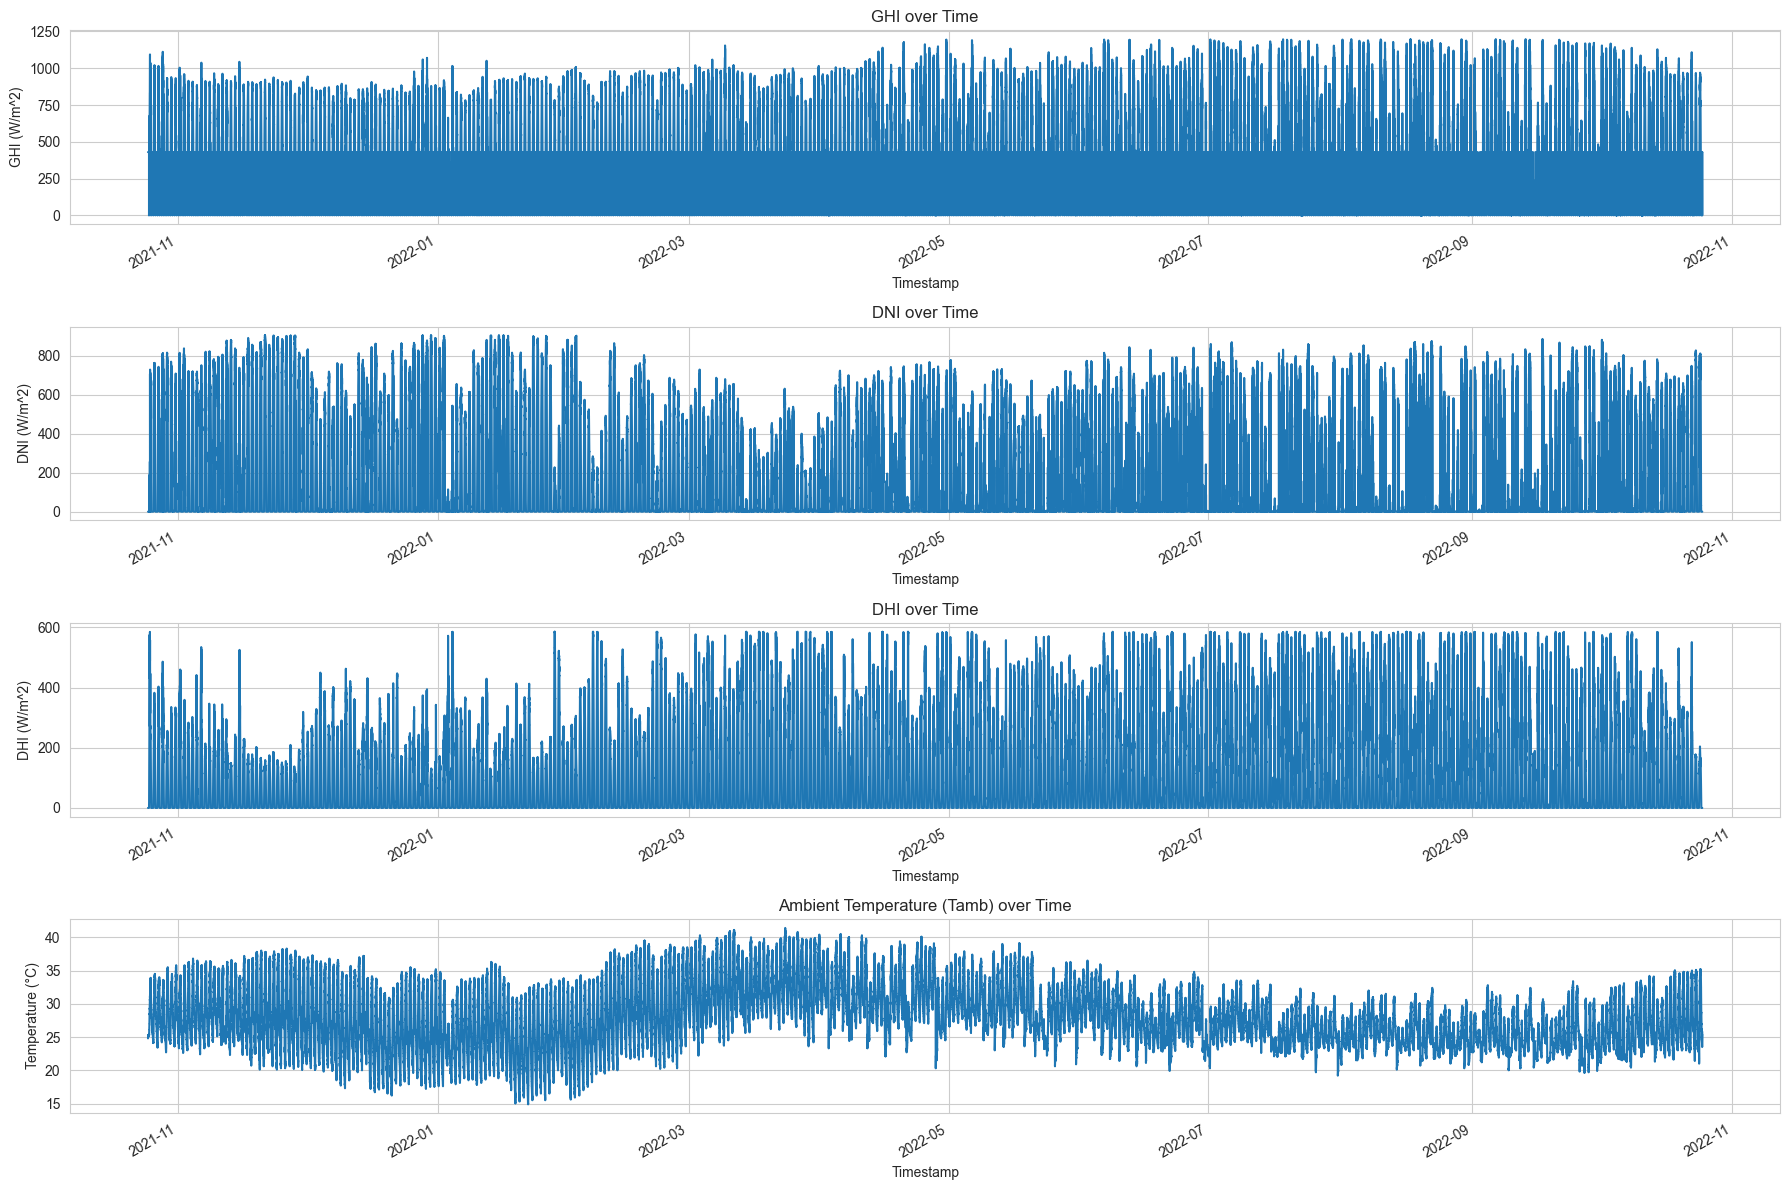

In [9]:
plt.figure(figsize=(18, 12))

plt.subplot(4, 1, 1)
df_benin_clean['GHI'].plot(title='GHI over Time')
plt.ylabel('GHI (W/m^2)')

plt.subplot(4, 1, 2)
df_benin_clean['DNI'].plot(title='DNI over Time')
plt.ylabel('DNI (W/m^2)')

plt.subplot(4, 1, 3)
df_benin_clean['DHI'].plot(title='DHI over Time')
plt.ylabel('DHI (W/m^2)')

plt.subplot(4, 1, 4)
df_benin_clean['Tamb'].plot(title='Ambient Temperature (Tamb) over Time')
plt.ylabel('Temperature (°C)')
plt.xlabel('Timestamp')

plt.tight_layout()
plt.show()

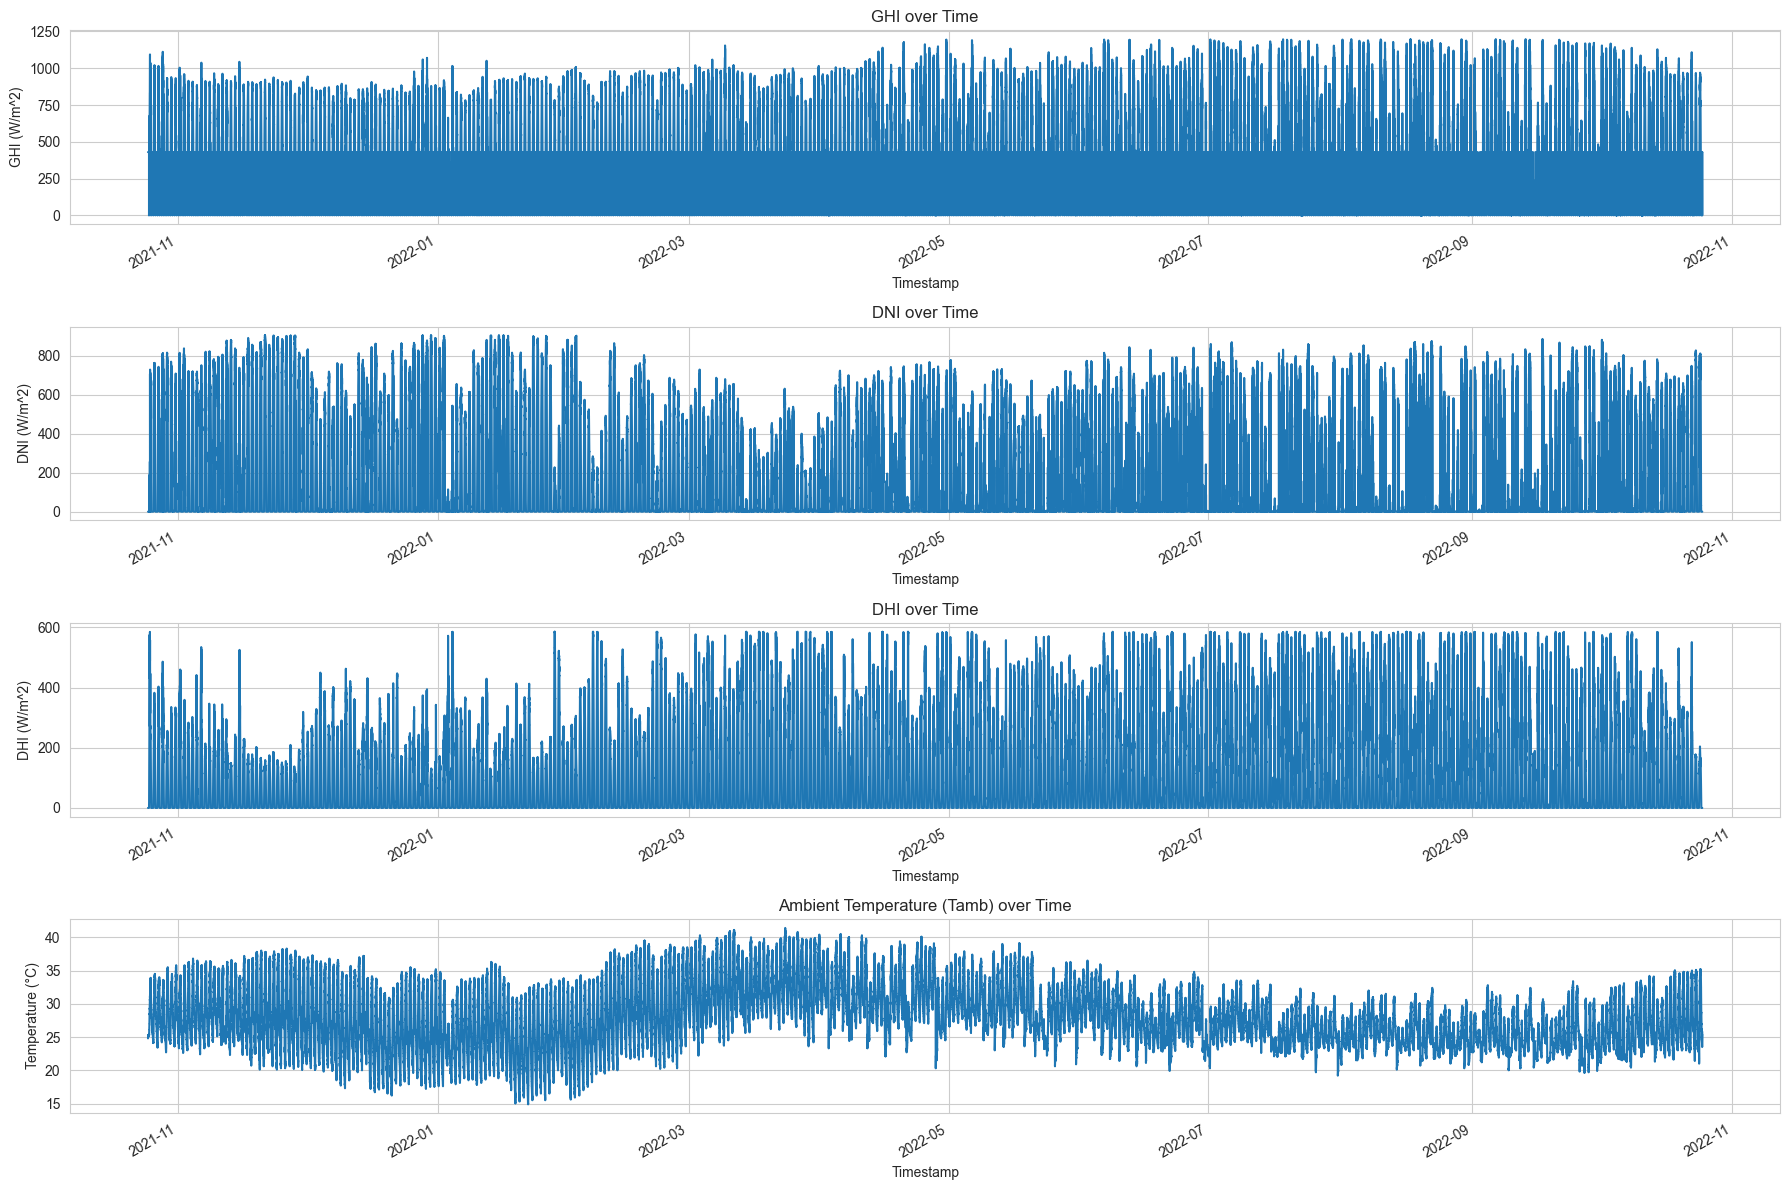

In [10]:
plt.figure(figsize=(18, 12))

plt.subplot(4, 1, 1)
df_benin_clean['GHI'].plot(title='GHI over Time')
plt.ylabel('GHI (W/m^2)')

plt.subplot(4, 1, 2)
df_benin_clean['DNI'].plot(title='DNI over Time')
plt.ylabel('DNI (W/m^2)')

plt.subplot(4, 1, 3)
df_benin_clean['DHI'].plot(title='DHI over Time')
plt.ylabel('DHI (W/m^2)')

plt.subplot(4, 1, 4)
df_benin_clean['Tamb'].plot(title='Ambient Temperature (Tamb) over Time')
plt.ylabel('Temperature (°C)')
plt.xlabel('Timestamp')

plt.tight_layout()
plt.show()

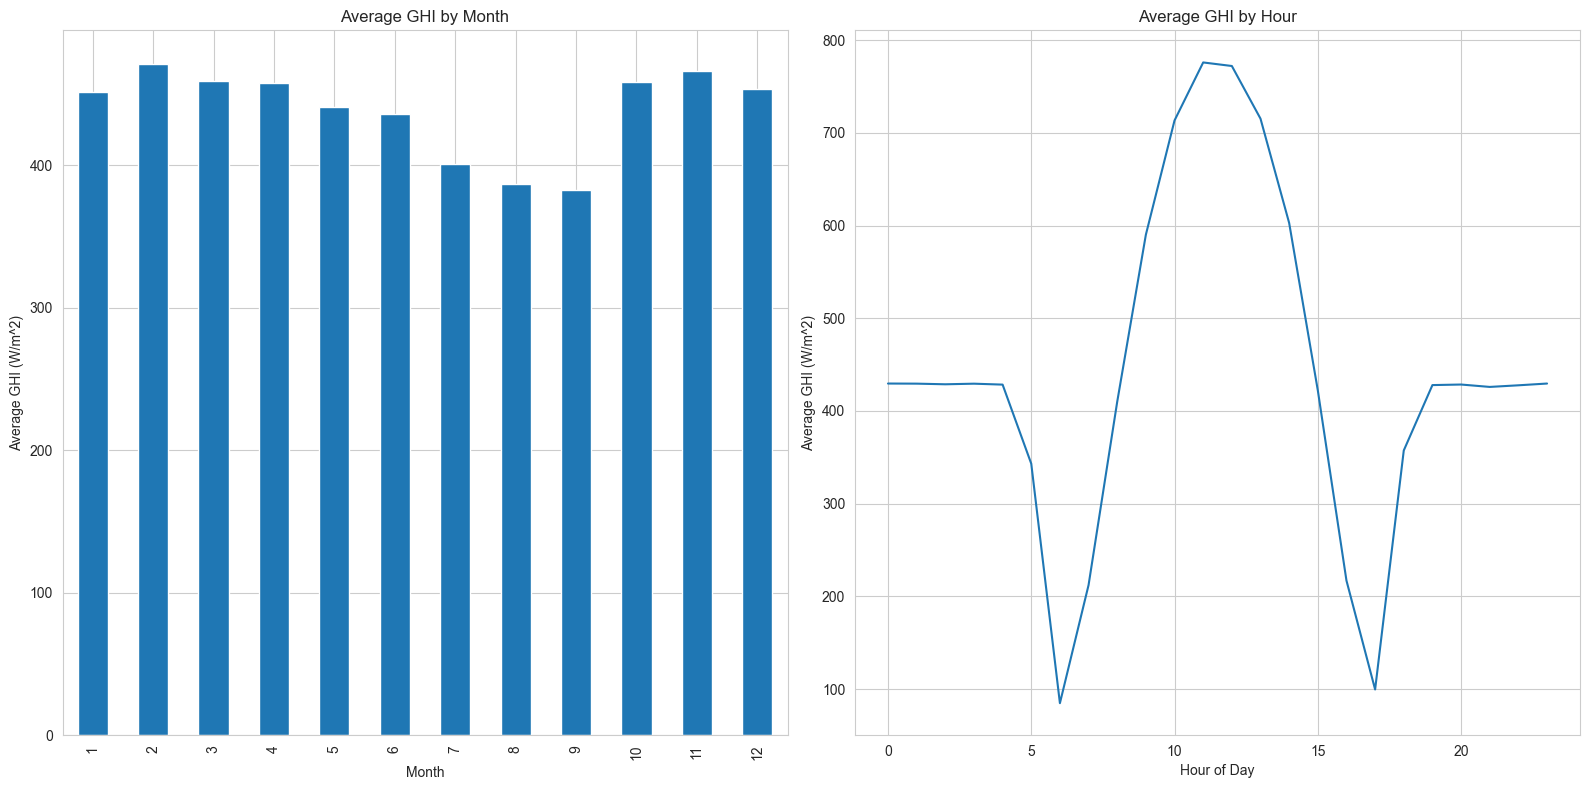

In [12]:
# Extract month and hour for pattern analysis
df_benin_clean['Month'] = df_benin_clean.index.month
df_benin_clean['Hour'] = df_benin_clean.index.hour

plt.figure(figsize=(16, 8))

# Monthly average GHI
plt.subplot(1, 2, 1)
df_benin_clean.groupby('Month')['GHI'].mean().plot(kind='bar')
plt.title('Average GHI by Month')
plt.xlabel('Month')
plt.ylabel('Average GHI (W/m^2)')

# Hourly average GHI
plt.subplot(1, 2, 2)
df_benin_clean.groupby('Hour')['GHI'].mean().plot(kind='line')
plt.title('Average GHI by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average GHI (W/m^2)')

plt.tight_layout()
plt.show()

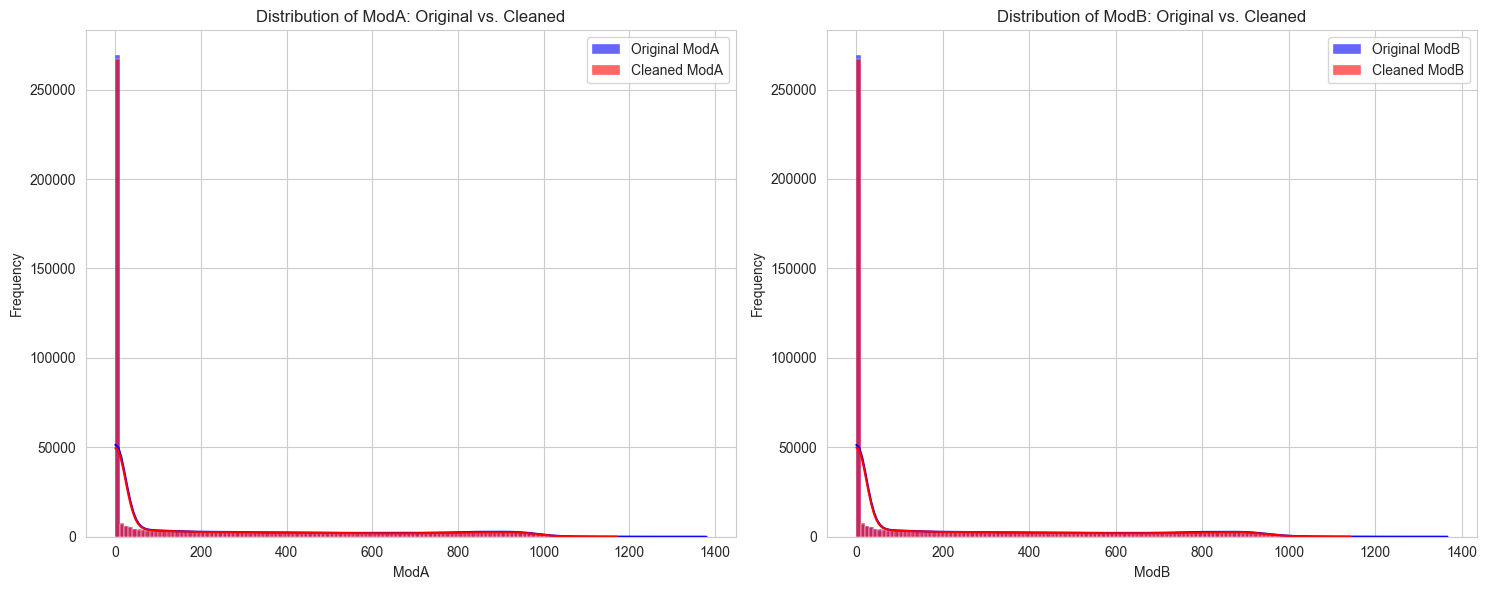


Summary Statistics for ModA (Original vs. Cleaned):
Original ModA:
 count    525600.000000
mean        226.144375
std         317.346938
min           0.000000
25%           0.000000
50%           4.400000
75%         422.525000
max        1380.000000
Name: ModA, dtype: float64

Cleaned ModA:
 count    516349.000000
mean        219.380751
std         311.854841
min           0.000000
25%           0.000000
50%           2.800000
75%         404.100000
max        1171.200000
Name: ModA, dtype: float64

Summary Statistics for ModB (Original vs. Cleaned):
Original ModB:
 count    525600.000000
mean        219.568588
std         307.932510
min           0.000000
25%           0.000000
50%           4.300000
75%         411.000000
max        1367.000000
Name: ModB, dtype: float64

Cleaned ModB:
 count    516349.000000
mean        213.028150
std         302.625802
min           0.000000
25%           0.000000
50%           2.800000
75%         393.100000
max        1143.000000
Name: ModB, d

In [13]:
# Re-load original data for comparison (or use the original df_benin before cleaning)
df_original_mod = pd.read_csv(file_path, parse_dates=['Timestamp']).set_index('Timestamp')

plt.figure(figsize=(15, 6))

# ModA comparison
plt.subplot(1, 2, 1)
sns.histplot(df_original_mod['ModA'].dropna(), color='blue', label='Original ModA', kde=True, alpha=0.6)
sns.histplot(df_benin_clean['ModA'], color='red', label='Cleaned ModA', kde=True, alpha=0.6)
plt.title('Distribution of ModA: Original vs. Cleaned')
plt.xlabel('ModA')
plt.ylabel('Frequency')
plt.legend()

# ModB comparison
plt.subplot(1, 2, 2)
sns.histplot(df_original_mod['ModB'].dropna(), color='blue', label='Original ModB', kde=True, alpha=0.6)
sns.histplot(df_benin_clean['ModB'], color='red', label='Cleaned ModB', kde=True, alpha=0.6)
plt.title('Distribution of ModB: Original vs. Cleaned')
plt.xlabel('ModB')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

# You can also look at summary statistics before/after for ModA and ModB
print("\nSummary Statistics for ModA (Original vs. Cleaned):")
print("Original ModA:\n", df_original_mod['ModA'].describe())
print("\nCleaned ModA:\n", df_benin_clean['ModA'].describe())

print("\nSummary Statistics for ModB (Original vs. Cleaned):")
print("Original ModB:\n", df_original_mod['ModB'].describe())
print("\nCleaned ModB:\n", df_benin_clean['ModB'].describe())

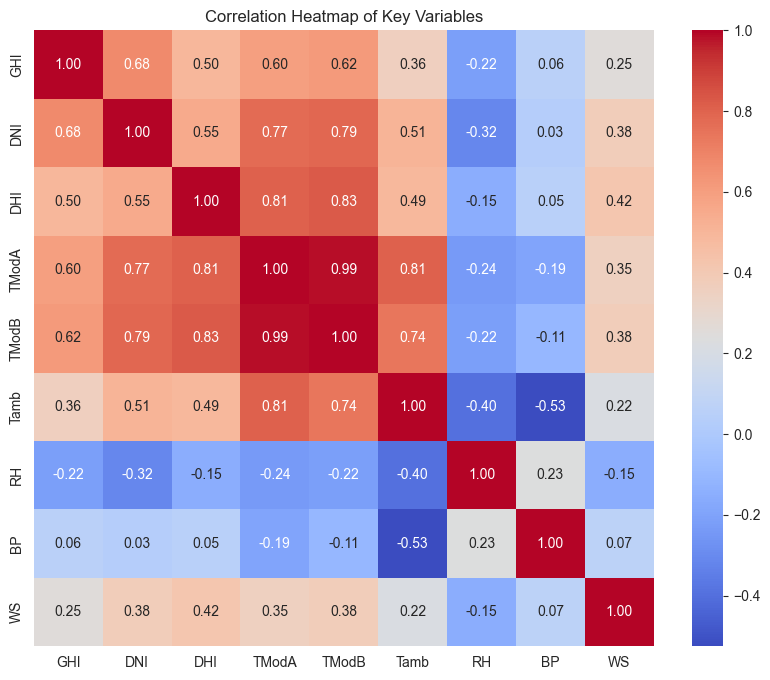

In [14]:
correlation_cols = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB', 'Tamb', 'RH', 'BP', 'WS'] # Added more for richer insights
corr_matrix = df_benin_clean[correlation_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Key Variables')
plt.show()

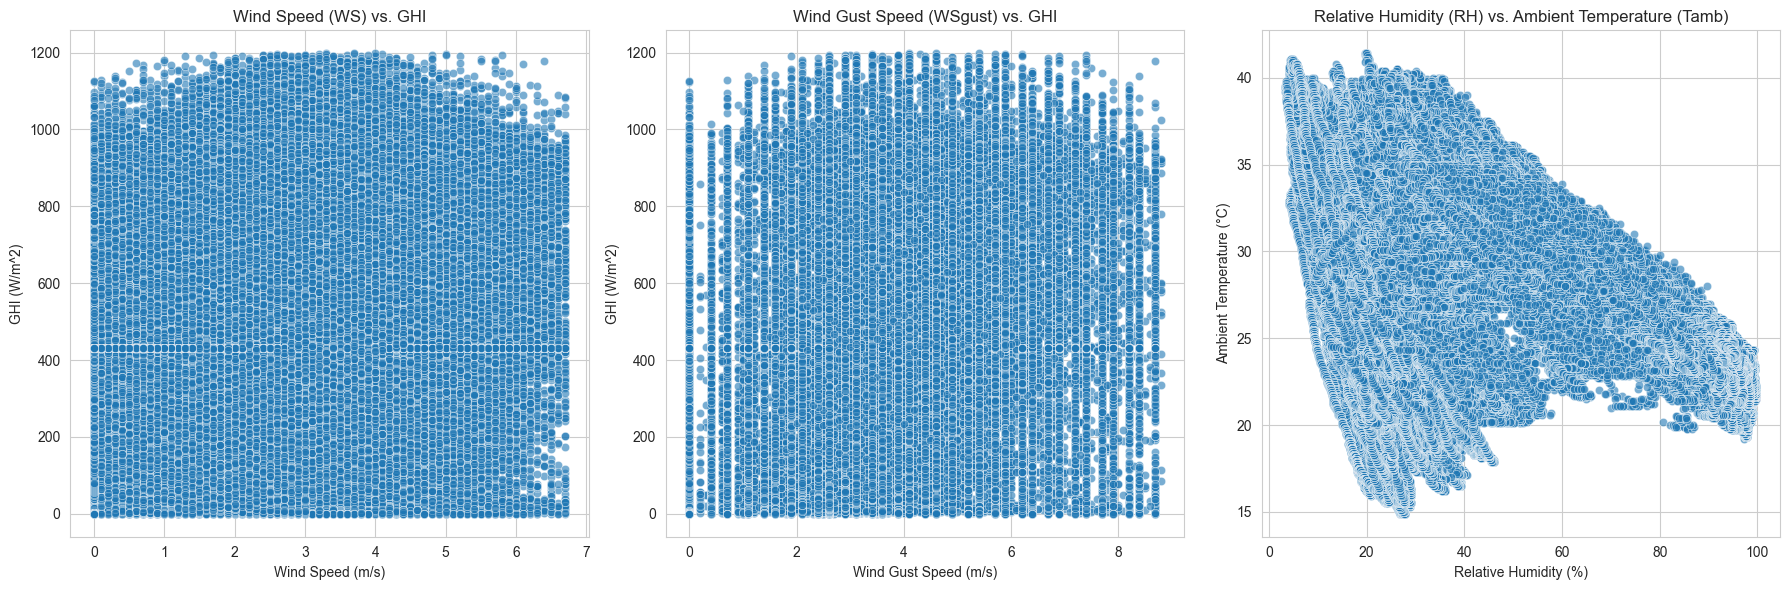

In [15]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(x='WS', y='GHI', data=df_benin_clean, alpha=0.6)
plt.title('Wind Speed (WS) vs. GHI')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('GHI (W/m^2)')

plt.subplot(1, 3, 2)
sns.scatterplot(x='WSgust', y='GHI', data=df_benin_clean, alpha=0.6)
plt.title('Wind Gust Speed (WSgust) vs. GHI')
plt.xlabel('Wind Gust Speed (m/s)')
plt.ylabel('GHI (W/m^2)')

plt.subplot(1, 3, 3)
sns.scatterplot(x='RH', y='Tamb', data=df_benin_clean, alpha=0.6)
plt.title('Relative Humidity (RH) vs. Ambient Temperature (Tamb)')
plt.xlabel('Relative Humidity (%)')
plt.ylabel('Ambient Temperature (°C)')

plt.tight_layout()
plt.show()

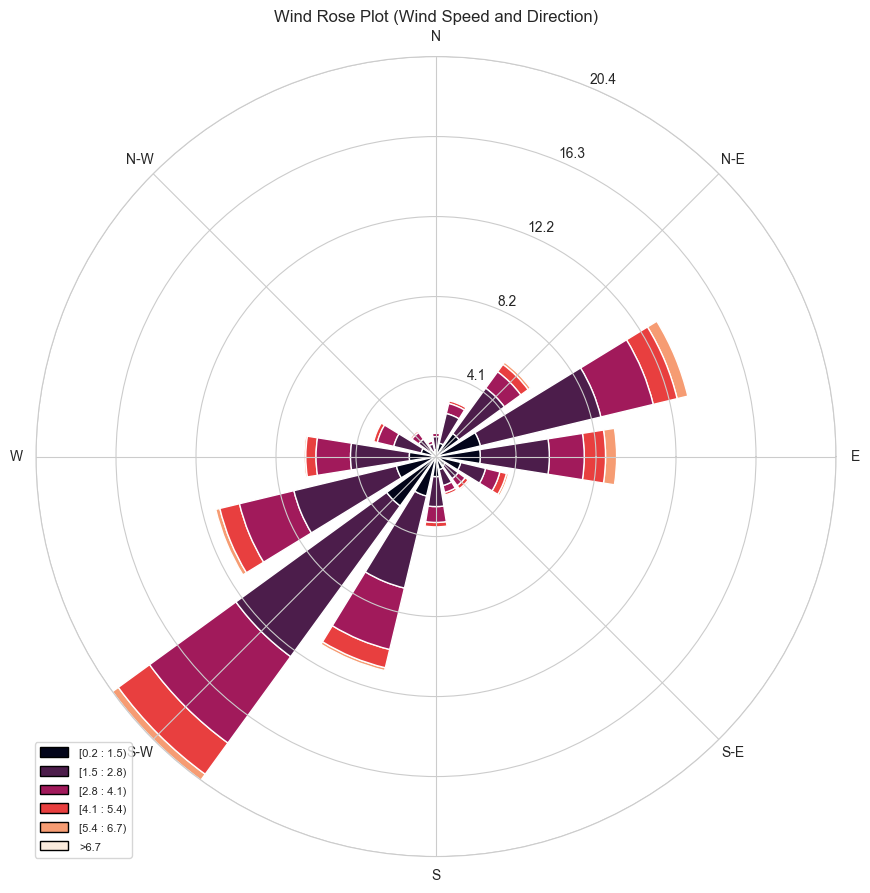

In [16]:
# Ensure WindroseAxes is imported and WS, WD are numeric
# Filter out zero wind speeds for clearer visualization in windrose
df_wind = df_benin_clean[(df_benin_clean['WS'] > 0.1) & (df_benin_clean['WD'].notna())].copy()

if not df_wind.empty:
    fig = plt.figure(figsize=(10, 10))
    ax = WindroseAxes.from_ax(fig=fig)
    ax.bar(df_wind['WD'], df_wind['WS'], normed=True, opening=0.8, edgecolor='white')
    ax.set_legend()
    plt.title('Wind Rose Plot (Wind Speed and Direction)')
    plt.show()
else:
    print("Not enough wind data with speed > 0.1 to plot wind rose.")